# Spotify Streaming Analytics
### Python • SQL • Pandas • Matplotlib • Plotly

## Problem Statement

Streaming platforms like Spotify generate massive datasets that contain:
- User listening behavior
- Time patterns (when people listen most)
- Popular songs that drive revenue

If this raw CSV data is exposed, attackers could:
- Infer business trends (which artists generate the most money)
- Steal proprietary analytics used for marketing and contracts
- Combine with other leaks to profile users

This project demonstrates how to **protect a real CSV dataset** (Spotify Christmas Hits, 2017–2025) using **Python and Fernet symmetric encryption**, inside a simple data pipeline:
1. Load the raw dataset
2. Perform basic analysis
3. Encrypt the file at rest
4. Decrypt and verify integrity
5. Encrypt the file at rest using Fernet (AES-128 + HMAC)
6. Decrypt and verify data integrity

**Tools used:** Python, Pandas, SQL, Plotly, Matplotlib, Fernet Encryption




## Project Architecture

This project follows a structured analytics pipeline:

1. Data Ingestion
   - Load Spotify Christmas streaming dataset (CSV)

2. Data Processing
   - Clean and structure data using Pandas
   - Perform SQL-style queries for analysis

3. Exploratory Data Analysis (EDA)
   - Identify streaming trends
   - Analyze seasonal listening patterns

4. Data Visualization
   - Build charts using Matplotlib
   - Create interactive dashboards with Plotly

5. Data Security Layer
   - Encrypt dataset using Fernet symmetric encryption (AES-128 + HMAC)
   - Verify data integrity before decryption and analysis

## Business Impact

This project demonstrates how data analytics pipelines transform raw streaming data into actionable insights about user behavior and seasonal demand.
By combining analysis, visualization, and encryption, it highlights how modern analytics systems must balance performance, insight generation, and data security.

📂 Load Dataset & Inspect Structure
In this section, we load the Spotify Christmas streaming dataset and inspect its structure to understand what we are working with.
We will answer:
What columns exist?
How many rows?
Any missing values?
The general structure of the dataset.

In [ ]:
import pandas as pd

# Mount Google Drive to access files from My Drive
from google.colab import drive
drive.mount('/content/drive')

# Load dataset
# Ensure the file 'spotify_christmas_streams_kworb_2017_2025.csv' is in your Google Drive's root 'My Drive' folder.
df = pd.read_csv("/content/drive/MyDrive/spotify_christmas_streams_kworb_2017_2025.csv")

# Show first rows
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,date,track,artist,streams,day_of_week,week_of_year
0,2017-11-16,All I Want for Christmas Is You,Mariah Carey,3821572,Thursday,46
1,2017-11-23,All I Want for Christmas Is You,Mariah Carey,6130250,Thursday,47
2,2017-11-23,Last Christmas,Wham!,4040197,Thursday,47
3,2017-11-30,All I Want for Christmas Is You,Mariah Carey,11641888,Thursday,48
4,2017-11-30,It's Beginning to Look a Lot Like Christmas,Michael Bublé,4577042,Thursday,48


In [ ]:
# Dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376 entries, 0 to 375
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          376 non-null    object
 1   track         376 non-null    object
 2   artist        376 non-null    object
 3   streams       376 non-null    int64 
 4   day_of_week   376 non-null    object
 5   week_of_year  376 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 17.8+ KB


In [ ]:
# Basic statistics for numeric columns
df.describe()

,streams,week_of_year
count,3.760000e+02,376.000000
mean,2.138968e+07,48.603723
std,1.460768e+07,5.888283
min,3.821572e+06,1.000000
25%,1.065505e+07,48.000000
50%,1.796841e+07,49.000000
75%,2.767923e+07,51.000000
max,9.250654e+07,53.000000


 Basic Data Exploration (EDA)
Before applying encryption, we extract simple insights to demonstrate data-analysis capability.
This makes the project a combination of Data Analytics + Cybersecurity, which is valuable for interviews.
We will explore:
The most streamed Christmas songs
Total streams grouped by year
Any patterns or anomalies

In [ ]:
# Top 10 most streamed songs (total streams)
top_songs = df.groupby("track")["streams"].sum().sort_values(ascending=False).head(10)
top_songs

,streams
track,
All I Want for Christmas Is You,1772401522
Last Christmas,1504418271
Rockin' Around the Christmas Tree,1162883008
Jingle Bell Rock,1028886045
Santa Tell Me,1013488311
It's Beginning to Look a Lot Like Christmas,927548499
Feliz Navidad,632895127


In [ ]:
# Convert 'date' column to datetime objects and extract the year
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

# Total streams per year
streams_by_year = df.groupby("year")["streams"].sum()
streams_by_year

,streams
year,
2017,359461696
2018,595483091
2019,610773167
2020,1007560272
2021,901269455
2022,1222813294
2023,1474219424
2024,1560494532
2025,310445852


### 📊 Visualization — Streams per Year

We create a visualization to show how Christmas music trends evolve over the years.
This demonstrates data storytelling and analytic skills.

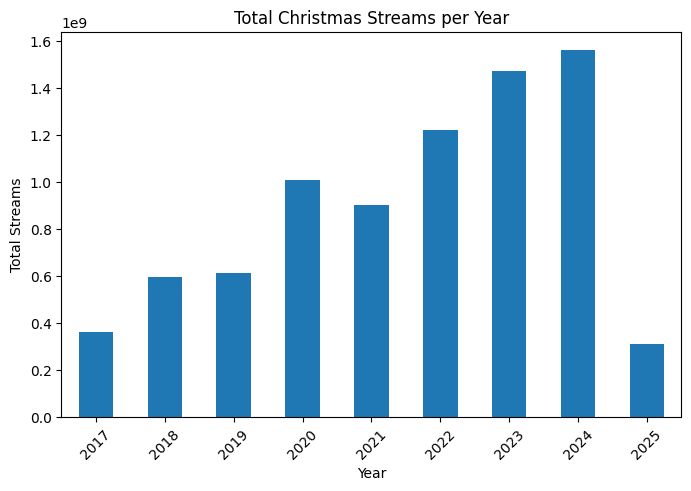

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
streams_by_year.plot(kind="bar")

plt.title("Total Christmas Streams per Year")
plt.xlabel("Year")
plt.ylabel("Total Streams")
plt.xticks(rotation=45)
plt.show()

### 🔐 Encryption Pipeline Functions

To polish the project and make it professional, we convert the encryption logic into reusable functions.
This improves code clarity, modularity, and aligns with secure engineering best practices.

We implement:
- Key generation & loading
- File encryption
- File decryption

In [ ]:
from cryptography.fernet import Fernet
import os

def generate_key(key_path="encryption_key.key"):
    """Generate and save a Fernet symmetric encryption key."""
    key = Fernet.generate_key()
    with open(key_path, "wb") as f:
        f.write(key)
    return key_path

def load_key(key_path="encryption_key.key"):
    """Load the encryption key from file."""
    with open(key_path, "rb") as f:
        return f.read()

def encrypt_file(input_path, output_path, key):
    """Encrypt a file using Fernet symmetric encryption."""
    fernet = Fernet(key)

    with open(input_path, "rb") as f:
        original_bytes = f.read()

    encrypted_bytes = fernet.encrypt(original_bytes)

    with open(output_path, "wb") as f:
        f.write(encrypted_bytes)

def decrypt_file(input_path, output_path, key):
    """Decrypt a previously encrypted file."""
    fernet = Fernet(key)

    with open(input_path, "rb") as f:
        encrypted_bytes = f.read()

    decrypted_bytes = fernet.decrypt(encrypted_bytes)

    with open(output_path, "wb") as f:
        f.write(decrypted_bytes)

### 🔏 Execute Encryption & Decryption

We now:
1. Generate a secure encryption key  
2. Encrypt the raw CSV dataset  
3. Restore it back to readable format  

In [ ]:
key_path = generate_key()
key = load_key(key_path)

encrypted_file = "spotify_encrypted.csv"
decrypted_file = "spotify_decrypted.csv"

encrypt_file("/content/drive/MyDrive/spotify_christmas_streams_kworb_2017_2025.csv", encrypted_file, key)
decrypt_file(encrypted_file, decrypted_file, key)

print("Encryption and decryption completed successfully.")

Encryption and decryption completed successfully.


### ✅ Verification — Check If Original and Decrypted Files Match

To validate the encryption pipeline, we verify that the decrypted file is
*identical* to the original dataset.  
If both byte sequences match, the encryption/decryption process is correct.

In [ ]:
# Read original and decrypted bytes
with open("/content/drive/MyDrive/spotify_christmas_streams_kworb_2017_2025.csv", "rb") as f:
    original_bytes = f.read()

with open(decrypted_file, "rb") as f:
    restored_bytes = f.read()

# Compare
print("Match:", original_bytes == restored_bytes)

Match: True


### ⏱️ Performance Metrics — File Size & Processing Time

To evaluate encryption overhead, we measure:
- File size before encryption
- File size after encryption
- Time required to encrypt and decrypt the dataset

In [ ]:
import os
import time

# Measure file sizes
original_size = os.path.getsize("/content/drive/MyDrive/spotify_christmas_streams_kworb_2017_2025.csv")
encrypted_size = os.path.getsize(encrypted_file)

print("Original size (KB):", original_size / 1024)
print("Encrypted size (KB):", encrypted_size / 1024)

# Measure time
start = time.time()
encrypt_file("/content/drive/MyDrive/spotify_christmas_streams_kworb_2017_2025.csv", encrypted_file, key)
encrypt_time = time.time() - start

start = time.time()
decrypt_file(encrypted_file, decrypted_file, key)
decrypt_time = time.time() - start

print("Encryption time (s):", encrypt_time)
print("Decryption time (s):", decrypt_time)

Original size (KB): 25.576171875
Encrypted size (KB): 34.1796875
Encryption time (s): 0.007528781890869141
Decryption time (s): 0.0009753704071044922


### 🛡️ Security Threat Model

#### What are we protecting?
- Streaming analytics (business-critical insights)
- Artist performance metrics that influence contracts
- Proprietary trend data used in marketing
- Potentially user behavior patterns

#### Potential Attackers
- External attackers exploiting misconfigured cloud storage
- Malicious insiders copying raw analytics files
- Competitors attempting to infer business strategy
- Data brokers harvesting listening trends

#### Why Use Fernet Symmetric Encryption?
- Built on AES-128 + HMAC (integrity protection)
- Fast enough for large CSV files
- Works well for “encrypt-at-rest” use cases
- Simple to integrate into ETL pipelines

#### Limitations
- If the key file is leaked → total compromise
- Must store keys in a secure vault (AWS KMS, Azure Key Vault, GCP KMS)
- Encryption alone is NOT security:
  - Access control is still required
  - Network protections are still required
  - Key rotation must be implemented

## 🗄️ SQL Analysis — Querying the Dataset

In this section, we replicate and extend our Pandas analysis using **SQL (SQLite)**.
The Spotify Christmas dataset is loaded into an in-memory SQL database,
allowing us to run structured queries for deeper insights.

This demonstrates the ability to work across both Python/Pandas and SQL workflows —
a critical skill in data engineering and analytics pipelines.

We will answer:
- Which songs have the highest total streams across all years?
- How have total Christmas streams grown year over year?
- What is the average stream performance per song per year?

In [ ]:
# SQL Analysis — Setup
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('spotify_christmas', conn, index=False, if_exists='replace')
print("Database created successfully.")

Database created successfully.


In [ ]:
# SQL Query 1 — Top 10 Most Streamed Songs
query1 = """
SELECT track, artist, SUM(streams) AS total_streams
FROM spotify_christmas
GROUP BY track, artist
ORDER BY total_streams DESC
LIMIT 10;
"""
top10_sql = pd.read_sql_query(query1, conn)
print(top10_sql)

                                         track          artist  total_streams
0              All I Want for Christmas Is You    Mariah Carey     1772401522
1                               Last Christmas           Wham!     1504418271
2            Rockin' Around the Christmas Tree      Brenda Lee     1162883008
3                             Jingle Bell Rock     Bobby Helms     1028886045
4                                Santa Tell Me   Ariana Grande     1013488311
5  It's Beginning to Look a Lot Like Christmas   Michael Bublé      927548499
6                                Feliz Navidad  José Feliciano      632895127


In [ ]:
# SQL Query 2 — Total Streams by Year
query2 = """
SELECT strftime('%Y', date) AS year,
       SUM(streams) AS total_streams
FROM spotify_christmas
GROUP BY year
ORDER BY year ASC;
"""
streams_by_year_sql = pd.read_sql_query(query2, conn)
print(streams_by_year_sql)

   year  total_streams
0  2017      359461696
1  2018      595483091
2  2019      610773167
3  2020     1007560272
4  2021      901269455
5  2022     1222813294
6  2023     1474219424
7  2024     1560494532
8  2025      310445852


In [ ]:
# SQL Query 3 — Average Streams per Song per Year
query3 = """
SELECT strftime('%Y', date) AS year,
       track,
       AVG(streams) AS avg_streams
FROM spotify_christmas
GROUP BY year, track
ORDER BY year ASC, avg_streams DESC;
"""
avg_streams_sql = pd.read_sql_query(query3, conn)
print(avg_streams_sql.head(10))

   year                                        track   avg_streams
0  2017              All I Want for Christmas Is You  1.626930e+07
1  2017                               Last Christmas  1.292028e+07
2  2017  It's Beginning to Look a Lot Like Christmas  9.071985e+06
3  2017                                Santa Tell Me  8.204700e+06
4  2017                             Jingle Bell Rock  8.125798e+06
5  2017            Rockin' Around the Christmas Tree  7.975274e+06
6  2017                                Feliz Navidad  6.385887e+06
7  2018              All I Want for Christmas Is You  2.053757e+07
8  2018                               Last Christmas  1.722705e+07
9  2018                                Santa Tell Me  1.507900e+07


In [ ]:
# Close SQL connection
conn.close()
print("SQL analysis complete.")

SQL analysis complete.


## 📊 Interactive Dashboard — Plotly Visualizations

In this section, we create interactive dashboards to visualize
the Spotify Christmas streaming data.

This replicates the kind of business intelligence dashboards
built in tools like Power BI and Tableau — using Python and Plotly.

We will visualize:
- Total Christmas streams by year (Bar Chart)
- Streaming growth trend over time (Line Chart)
- Top 10 most streamed songs (Horizontal Bar)

In [ ]:
# Install and import Plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

print("Plotly ready.")

Plotly ready.


In [ ]:
# Chart 1 — Total Christmas Streams by Year (Bar Chart)
streams_by_year = df.groupby("year")["streams"].sum().reset_index()

fig1 = px.bar(
    streams_by_year,
    x="year",
    y="streams",
    title="🎄 Total Christmas Streams per Year (2017–2025)",
    labels={"streams": "Total Streams", "year": "Year"},
    color="streams",
    color_continuous_scale="Greens"
)
fig1.update_layout(showlegend=False)
fig1.show()

In [ ]:
# Chart 2 — Streaming Growth Trend (Line Chart)
fig2 = px.line(
    streams_by_year,
    x="year",
    y="streams",
    title="📈 Christmas Streaming Growth Trend (2017–2025)",
    labels={"streams": "Total Streams", "year": "Year"},
    markers=True,
    line_shape="spline"
)
fig2.update_traces(line_color="green", line_width=3)
fig2.show()

In [ ]:
# Chart 3 — Top 10 Most Streamed Songs (Horizontal Bar)
top10 = df.groupby("track")["streams"].sum().sort_values(
    ascending=False).head(10).reset_index()

fig3 = px.bar(
    top10,
    x="streams",
    y="track",
    orientation="h",
    title="🎵 Top 10 Most Streamed Christmas Songs (All Time)",
    labels={"streams": "Total Streams", "track": "Song"},
    color="streams",
    color_continuous_scale="Greens"
)
fig3.update_layout(yaxis={"categoryorder": "total ascending"})
fig3.show()

In [ ]:
# Chart 4 — Full Dashboard (All charts together)
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig4 = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Total Streams by Year",
        "Growth Trend",
        "Top 10 Songs",
        "Avg Streams per Year"
    )
)

# Bar chart
fig4.add_trace(go.Bar(
    x=streams_by_year["year"],
    y=streams_by_year["streams"],
    name="Total Streams",
    marker_color="green"
), row=1, col=1)

# Line chart
fig4.add_trace(go.Scatter(
    x=streams_by_year["year"],
    y=streams_by_year["streams"],
    mode="lines+markers",
    name="Growth Trend",
    line=dict(color="darkgreen", width=2)
), row=1, col=2)

# Horizontal bar
fig4.add_trace(go.Bar(
    x=top10["streams"],
    y=top10["track"],
    orientation="h",
    name="Top 10 Songs",
    marker_color="lightgreen"
), row=2, col=1)

# Average streams per year
avg_per_year = df.groupby("year")["streams"].mean().reset_index()
fig4.add_trace(go.Scatter(
    x=avg_per_year["year"],
    y=avg_per_year["streams"],
    mode="lines+markers",
    name="Avg Streams",
    line=dict(color="seagreen", width=2)
), row=2, col=2)

fig4.update_layout(
    height=700,
    title_text="🎄 Spotify Christmas Streams — Full Analytics Dashboard",
    showlegend=False
)
fig4.show()

In [ ]:
print("✅ Dashboard complete.")
print("Charts built: Bar, Line, Horizontal Bar, Combined Dashboard")
print("Tools used: Python, Pandas, Plotly, SQL, Fernet Encryption")

✅ Dashboard complete.
Charts built: Bar, Line, Horizontal Bar, Combined Dashboard
Tools used: Python, Pandas, Plotly, SQL, Fernet Encryption
